# Final Evaluation (Validation + Test)

This notebook compares the focal model in two modes:
- Classifier head (standard softmax)
- Embedding k-NN (head removed or ignored)

ArcFace and Triplet runs are evaluated only with k-NN.


## Setup and Imports

Load evaluation utilities and register the experiment checkpoints to run.


In [1]:
import numpy as np
import torch
from pathlib import Path

from config import ExperimentConfig
from dataset import (
    build_dataloaders,
    build_retrieval_eval_loaders,
    build_test_loader,
    prepare_data,
)
from final_evaluation import (
    calculate_map5,
    evaluate_base_metrics,
    get_classifier_predictions,
    get_retrieval_predictions,
    insert_new_whale,
    sweep_thresholds,
)
from models import build_model
from visualization import plot_evaluation, plot_evaluation_pair

# Experiment artifacts to evaluate.
experiments = {
    "cross_entropy": {
        "label": "Cross Entropy",
        "config": "experiments/20260524_230915_baseline_effnetb5_cross_entrop_a55bddfe/config.json",
        "checkpoint": "experiments/20260524_230915_baseline_effnetb5_cross_entrop_a55bddfe/checkpoints/best.pth",
    },
    "focal": {
        "label": "Focal",
        "config": "experiments/20260526_171819_baseline_effnetb5_focal_d1f9c83d/config.json",
        "checkpoint": "experiments/20260526_171819_baseline_effnetb5_focal_d1f9c83d/checkpoints/best.pth",
    },
    "arcface": {
        "label": "ArcFace",
        "config": "experiments/20260527_171122_arcface_effnetb5_2bb8ad39/config.json",
        "checkpoint": "experiments/20260527_171122_arcface_effnetb5_2bb8ad39/checkpoints/best.pth",
    },
    "triplet": {
        "label": "Triplet",
        "config": "experiments/20260527_195128_triplet_effnetb5_e7fa63cf/config.json",
        "checkpoint": "experiments/20260527_195128_triplet_effnetb5_e7fa63cf/checkpoints/best.pth",
    },
    "contrastive": {
        "label": "Contrastive",
        "config": "experiments/20260527_224910_contrastive_effnetb5_31746b7c/config.json",
        "checkpoint": "experiments/20260527_224910_contrastive_effnetb5_31746b7c/checkpoints/best.pth",
    },
}

def is_experiment_available(info: dict) -> bool:
    return Path(info["config"]).exists() and Path(info["checkpoint"]).exists()


/root/ML4CV/models.py:65: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


## Loaders and Checkpoints

Helper to load config, data splits, loaders, and model weights per experiment.
Supports optional head override for k-NN-only evaluation.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from dataset import get_eval_config_and_data

config, data = get_eval_config_and_data()
gallery_loader, val_loader = build_retrieval_eval_loaders(config, data)
test_loader = build_test_loader(config, data)


def load_experiment(info, mode: str = "knn"):
    config = ExperimentConfig.load(info["config"])
    model = build_model(config, data["num_classes"], device)
    state = torch.load(info["checkpoint"], map_location=device, weights_only=False)
    model_state = state.get("model_state_dict", state)
    model.load_state_dict(model_state)
    model.eval()

    return config, data, model

Split (seed=42): train=7452 (4250 cls), val=1217 (405 new_whale), test=1181 (405 new_whale)


## Validation Sweep

Find the best open-set threshold on the validation split for each run.


In [3]:
runs = [
    {
        "run_id": "cross_entropy_knn",
        "exp_key": "cross_entropy",
        "mode": "knn",
        "label": "Cross Entropy - kNN",
    },
    {
        "run_id": "cross_entropy_cls",
        "exp_key": "cross_entropy",
        "mode": "classifier",
        "label": "Cross Entropy - Classifier",
    },
    {
        "run_id": "focal_cls",
        "exp_key": "focal",
        "mode": "classifier",
        "label": "Focal - Classifier",
    },
    {
        "run_id": "focal_knn",
        "exp_key": "focal",
        "mode": "knn",
        "label": "Focal - kNN",
    },
    {
        "run_id": "arcface_knn",
        "exp_key": "arcface",
        "mode": "knn",
        "label": "ArcFace - kNN",
    },
    {
        "run_id": "arcface_cls",
        "exp_key": "arcface",
        "mode": "classifier",
        "label": "ArcFace - Classifier",
    },
    {
        "run_id": "triplet_knn",
        "exp_key": "triplet",
        "mode": "knn",
        "label": "Triplet - kNN",
    },
        {
        "run_id": "contrastive_knn",
        "exp_key": "contrastive",
        "mode": "knn",
        "label": "Contrastive - kNN",
    },
]

results = {}

In [4]:
for run in runs:
    info = experiments.get(run["exp_key"])
    if info is None or not is_experiment_available(info):
        print(f"Skipping {run['run_id']}: missing config or checkpoint")
        continue

    print(f"\n=== {run['label']} ===")
    config, data, model = load_experiment(
        info, mode=run["mode"]
    )

    # Validation predictions for threshold sweep.
    if run["mode"] == "classifier":
        if config.head_type is None:
            print("  Skipping classifier mode because head_type is None")
            continue
        scores, preds, labels = get_classifier_predictions(model, val_loader, device)
    else:
        scores, preds, labels = get_retrieval_predictions(
            model, gallery_loader, val_loader, device
        )

    base_metrics = evaluate_base_metrics(scores, preds, labels)
    thresholds, map_scores, best_t, best_map = sweep_thresholds(scores, preds, labels)

    results[run["run_id"]] = {
        "label": run["label"],
        "mode": run["mode"],
        "exp_key": run["exp_key"],
        "base_metrics": base_metrics,
        "best_threshold": best_t,
        "best_map5": best_map,
        "thresholds": thresholds,
        "map_scores": map_scores,
    }

    print("Base Validation Metrics:", base_metrics)
    print(f"Optimal Validation Threshold: {best_t:.3f} -> MAP@5: {best_map:.4f}")


=== Cross Entropy - kNN ===


  Extracting embeddings:   0%|          | 0/311 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/51 [00:00<?, ?it/s]

Computing k-NN:   0%|          | 0/3 [00:00<?, ?it/s]

Sweeping Thresholds:   0%|          | 0/100 [00:00<?, ?it/s]

...

  Extracting embeddings:   0%|          | 0/311 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/51 [00:00<?, ?it/s]

Computing k-NN:   0%|          | 0/3 [00:00<?, ?it/s]

Sweeping Thresholds:   0%|          | 0/100 [00:00<?, ?it/s]

Base Validation Metrics: {'known_recall@1': 0.7807881832122803, 'known_recall@5': 0.8534482717514038, 'mean_known_conf': 0.9043411016464233, 'mean_new_whale_conf': 0.8728777170181274}
Optimal Validation Threshold: 0.859 -> MAP@5: 0.7276


## Test Evaluation

Apply the validation threshold to test and report the final MAP@5.
Classifier vs k-NN plots are stacked for the focal run.



=== Cross Entropy - kNN (test) ===


  Extracting embeddings:   0%|          | 0/311 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/50 [00:00<?, ?it/s]

Computing k-NN:   0%|          | 0/3 [00:00<?, ?it/s]

Test Base Metrics: {'known_recall@1': 0.5863401889801025, 'known_recall@5': 0.7164948582649231, 'mean_known_conf': 0.7924043536186218, 'mean_new_whale_conf': 0.790086030960083}
Final Test MAP@5: 0.6310


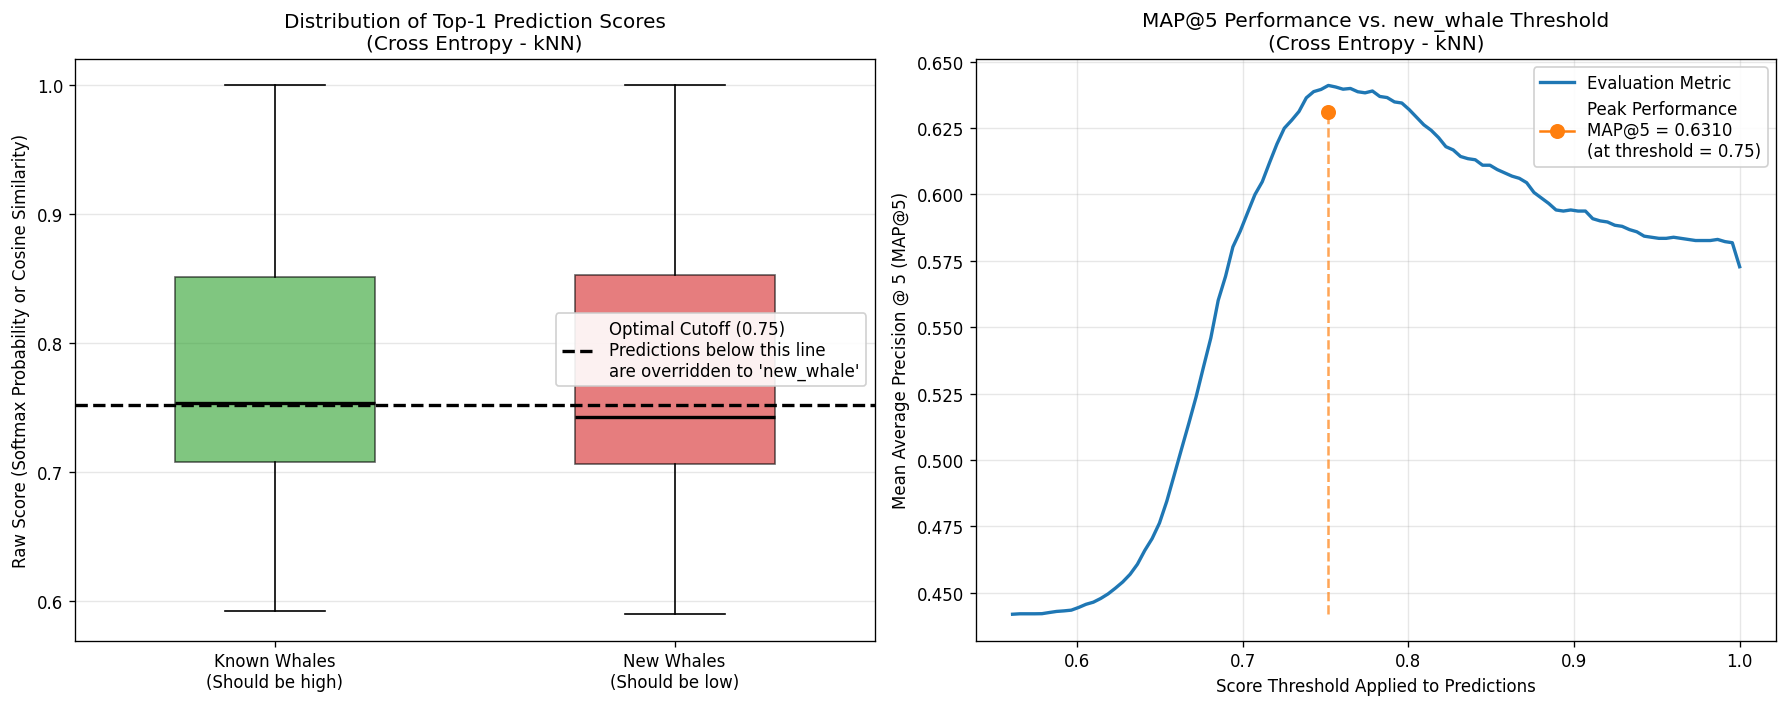


=== Cross Entropy - Classifier (test) ===


Extracting Classifier Preds:   0%|          | 0/50 [00:00<?, ?it/s]

Test Base Metrics: {'known_recall@1': 0.5451030731201172, 'known_recall@5': 0.6597937941551208, 'mean_known_conf': 0.7162023186683655, 'mean_new_whale_conf': 0.6753938794136047}
Final Test MAP@5: 0.6102


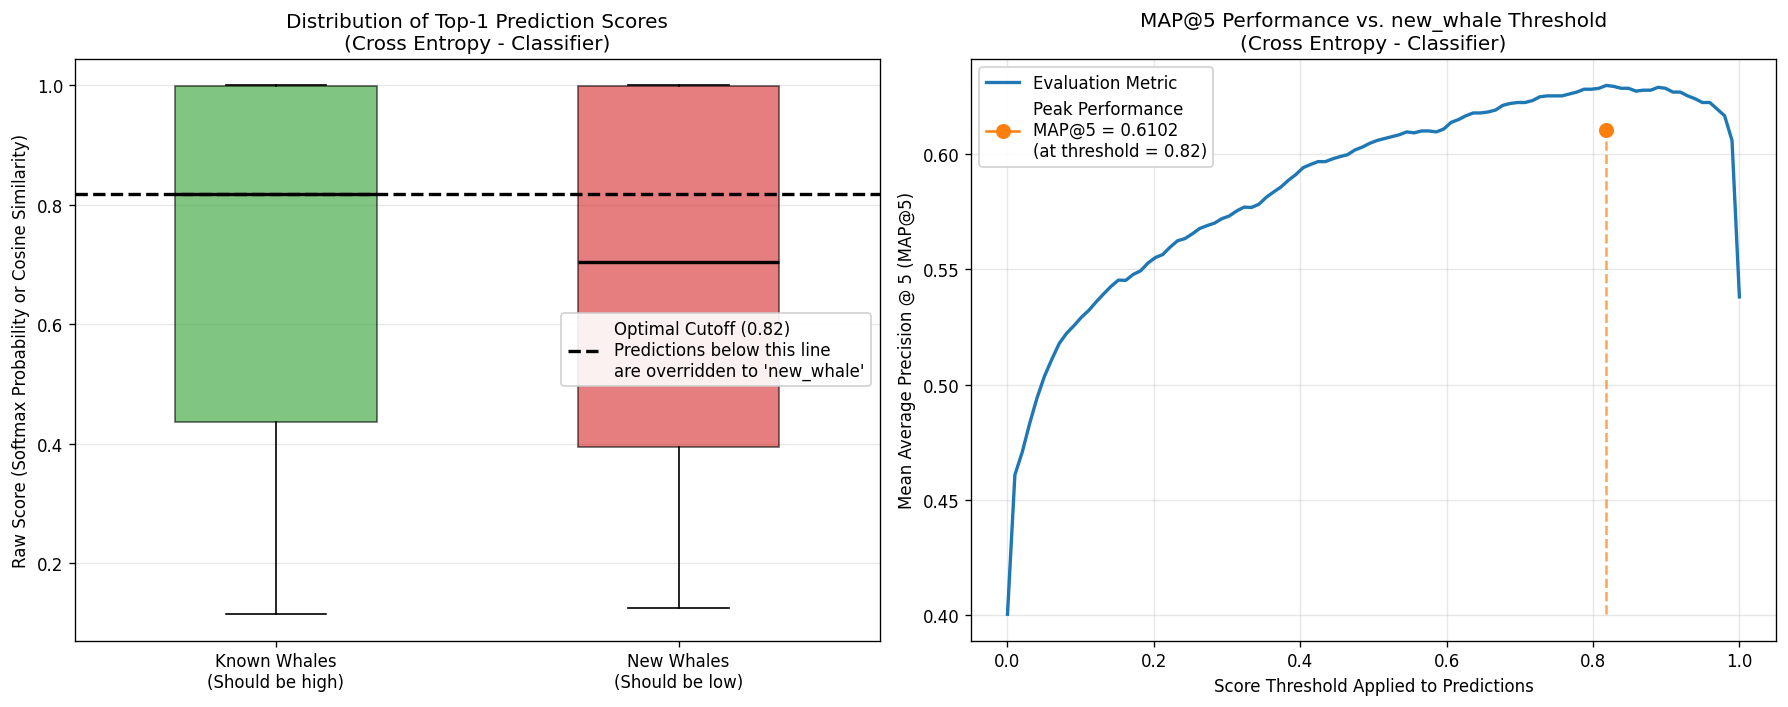


=== Focal - Classifier (test) ===


Extracting Classifier Preds:   0%|          | 0/50 [00:00<?, ?it/s]

Test Base Metrics: {'known_recall@1': 0.4845360815525055, 'known_recall@5': 0.6134020686149597, 'mean_known_conf': 0.20015449821949005, 'mean_new_whale_conf': 0.19057302176952362}
Final Test MAP@5: 0.5888


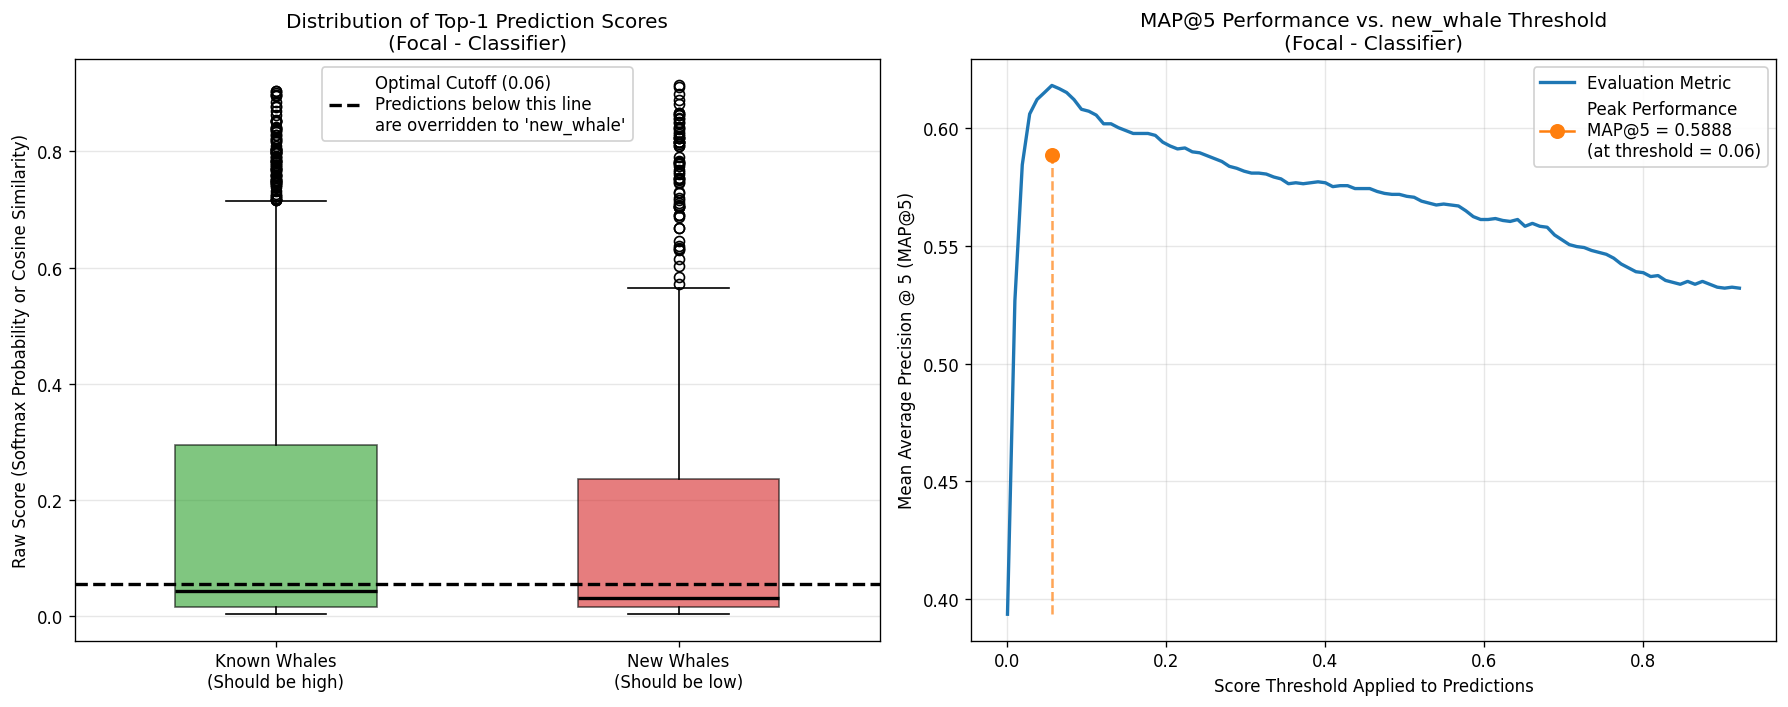


=== Focal - kNN (test) ===


  Extracting embeddings:   0%|          | 0/311 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/50 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f1c4e1027a0>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/venv/main/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f1c4e1027a0>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", l

Computing k-NN:   0%|          | 0/3 [00:00<?, ?it/s]

Test Base Metrics: {'known_recall@1': 0.5154638886451721, 'known_recall@5': 0.6417526006698608, 'mean_known_conf': 0.7659078240394592, 'mean_new_whale_conf': 0.7654204964637756}
Final Test MAP@5: 0.5917


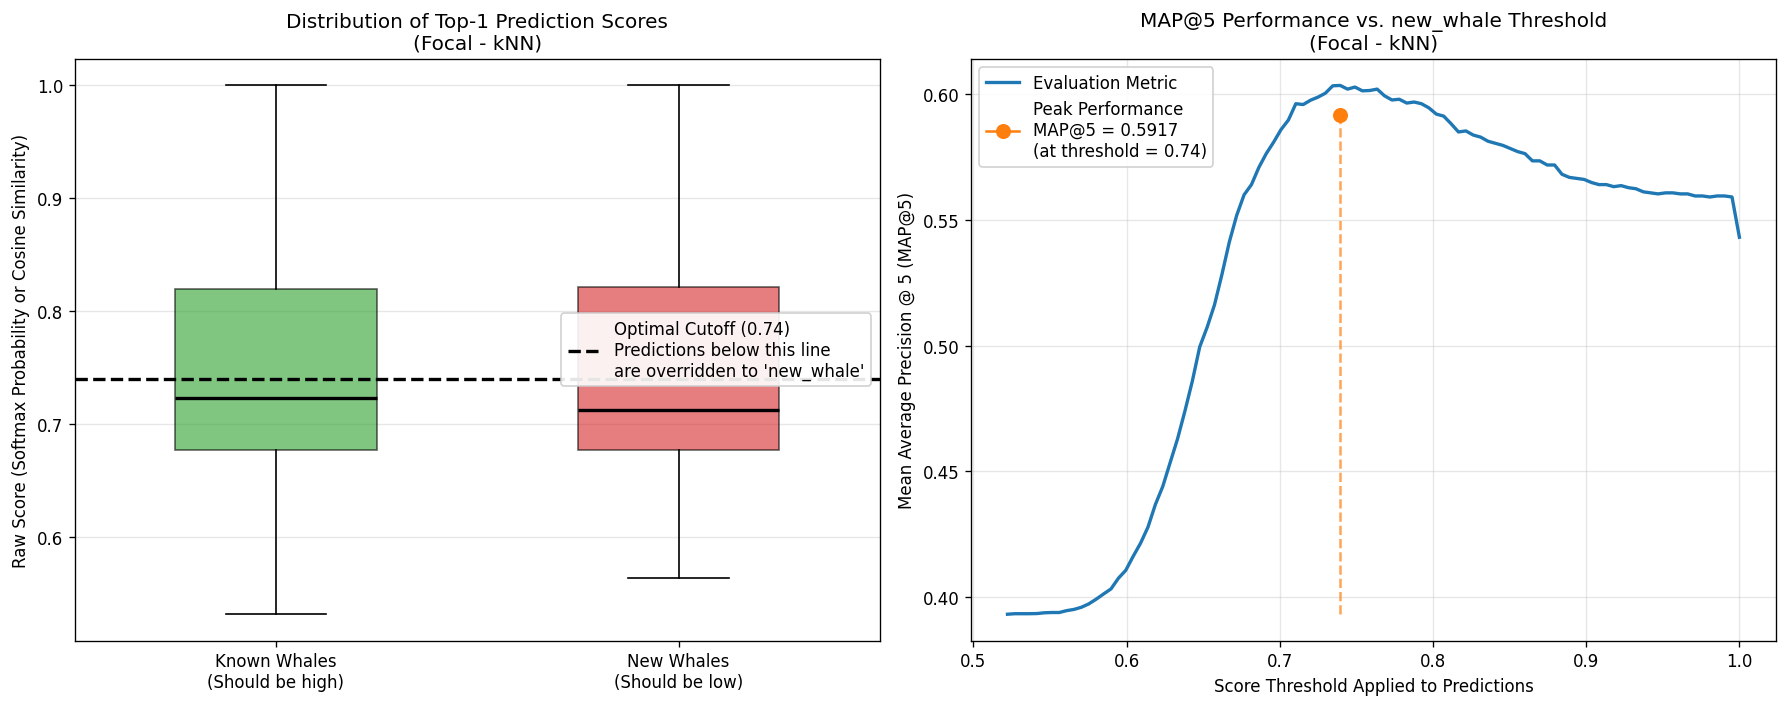


=== ArcFace - kNN (test) ===


  Extracting embeddings:   0%|          | 0/311 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/50 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f1c4e1027a0>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/venv/main/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f1c4e1027a0>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", l

Computing k-NN:   0%|          | 0/3 [00:00<?, ?it/s]

Test Base Metrics: {'known_recall@1': 0.6121134161949158, 'known_recall@5': 0.7010309100151062, 'mean_known_conf': 0.6810147762298584, 'mean_new_whale_conf': 0.6512599587440491}
Final Test MAP@5: 0.6542


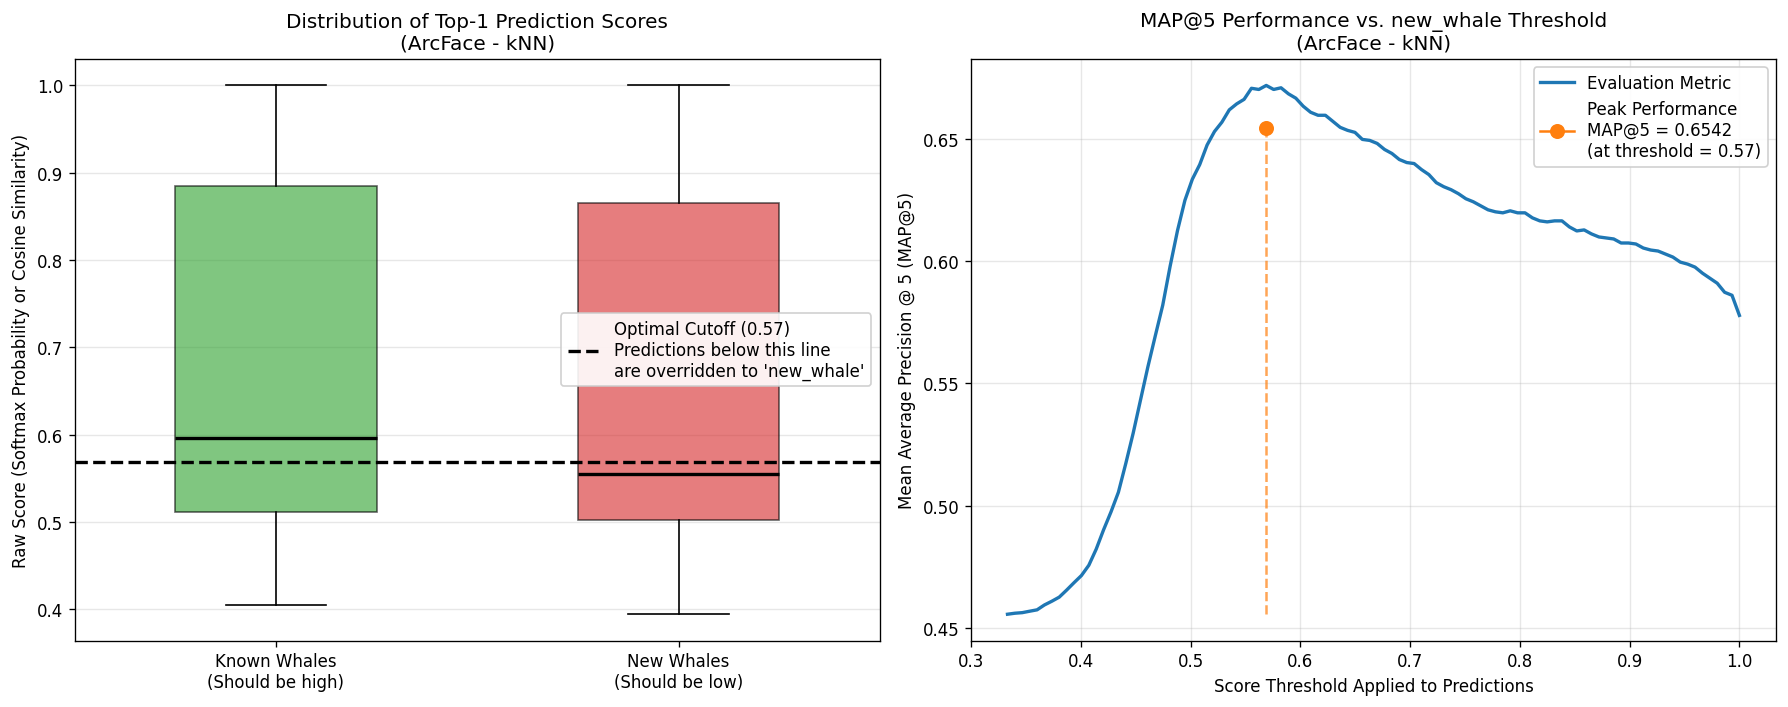


=== ArcFace - Classifier (test) ===


Extracting Classifier Preds:   0%|          | 0/50 [00:00<?, ?it/s]

Test Base Metrics: {'known_recall@1': 0.6121134161949158, 'known_recall@5': 0.7100515365600586, 'mean_known_conf': 0.6223986148834229, 'mean_new_whale_conf': 0.5067486763000488}
Final Test MAP@5: 0.6601


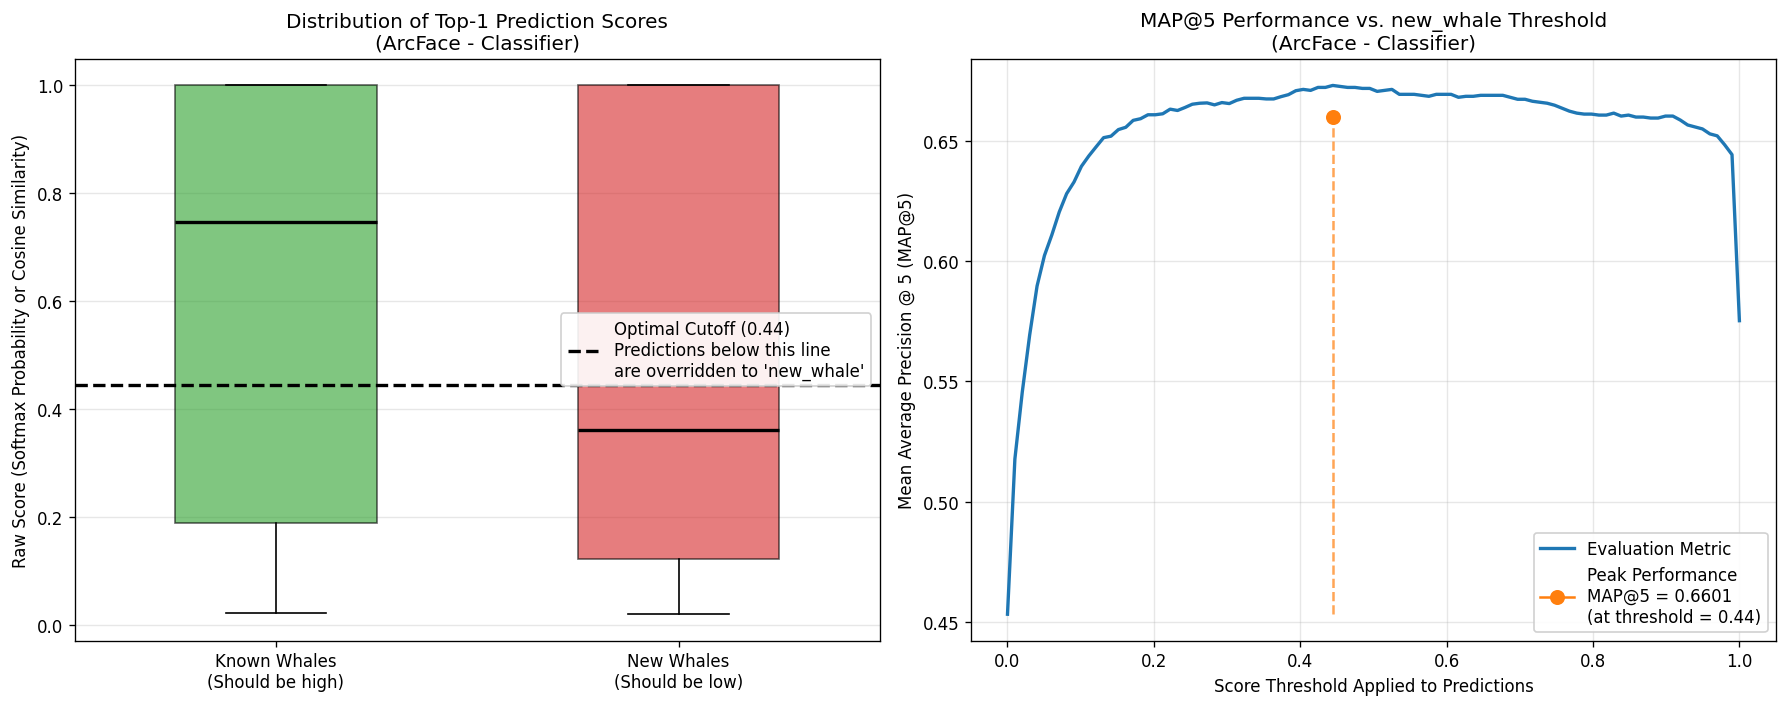


=== Triplet - kNN (test) ===


  Extracting embeddings:   0%|          | 0/311 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/50 [00:00<?, ?it/s]

Computing k-NN:   0%|          | 0/3 [00:00<?, ?it/s]

Test Base Metrics: {'known_recall@1': 0.7100515365600586, 'known_recall@5': 0.8015463948249817, 'mean_known_conf': 0.9091301560401917, 'mean_new_whale_conf': 0.9018187522888184}
Final Test MAP@5: 0.6766


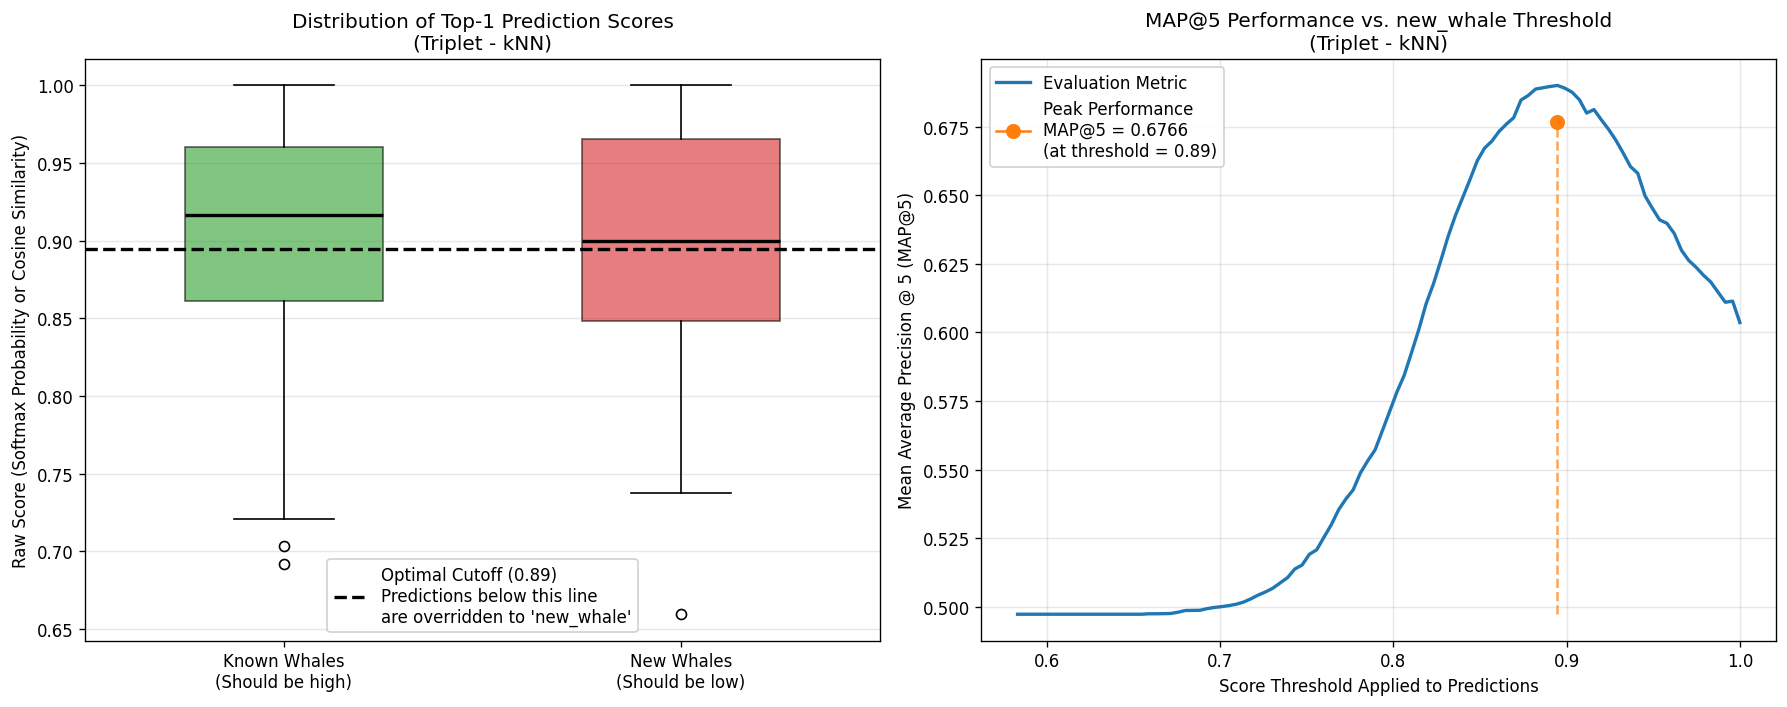


=== Contrastive - kNN (test) ===


  Extracting embeddings:   0%|          | 0/311 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/50 [00:00<?, ?it/s]

Computing k-NN:   0%|          | 0/3 [00:00<?, ?it/s]

Test Base Metrics: {'known_recall@1': 0.7641752362251282, 'known_recall@5': 0.8492268323898315, 'mean_known_conf': 0.901841938495636, 'mean_new_whale_conf': 0.8758910894393921}
Final Test MAP@5: 0.7226


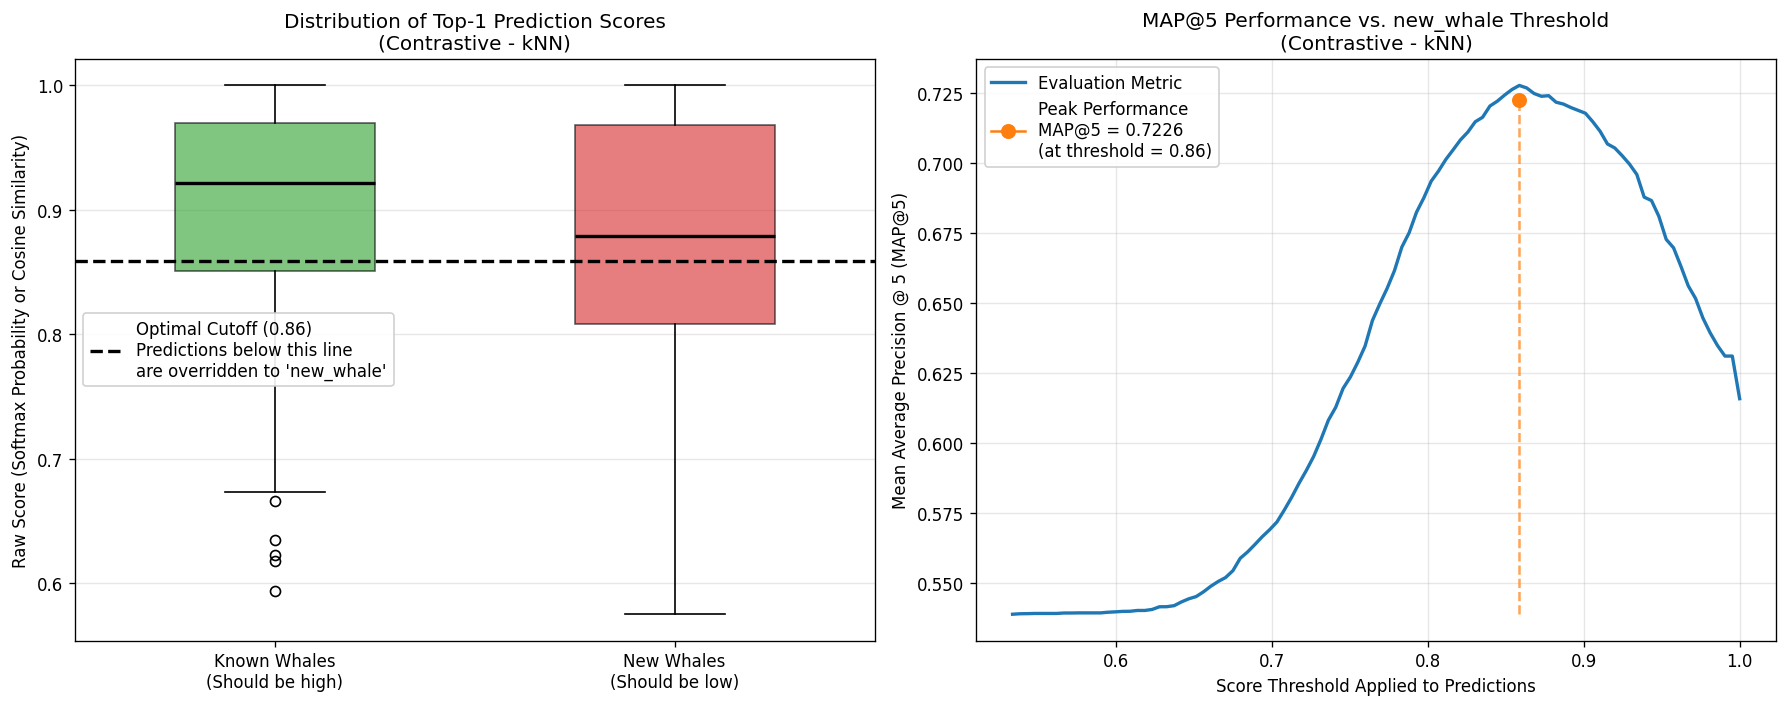

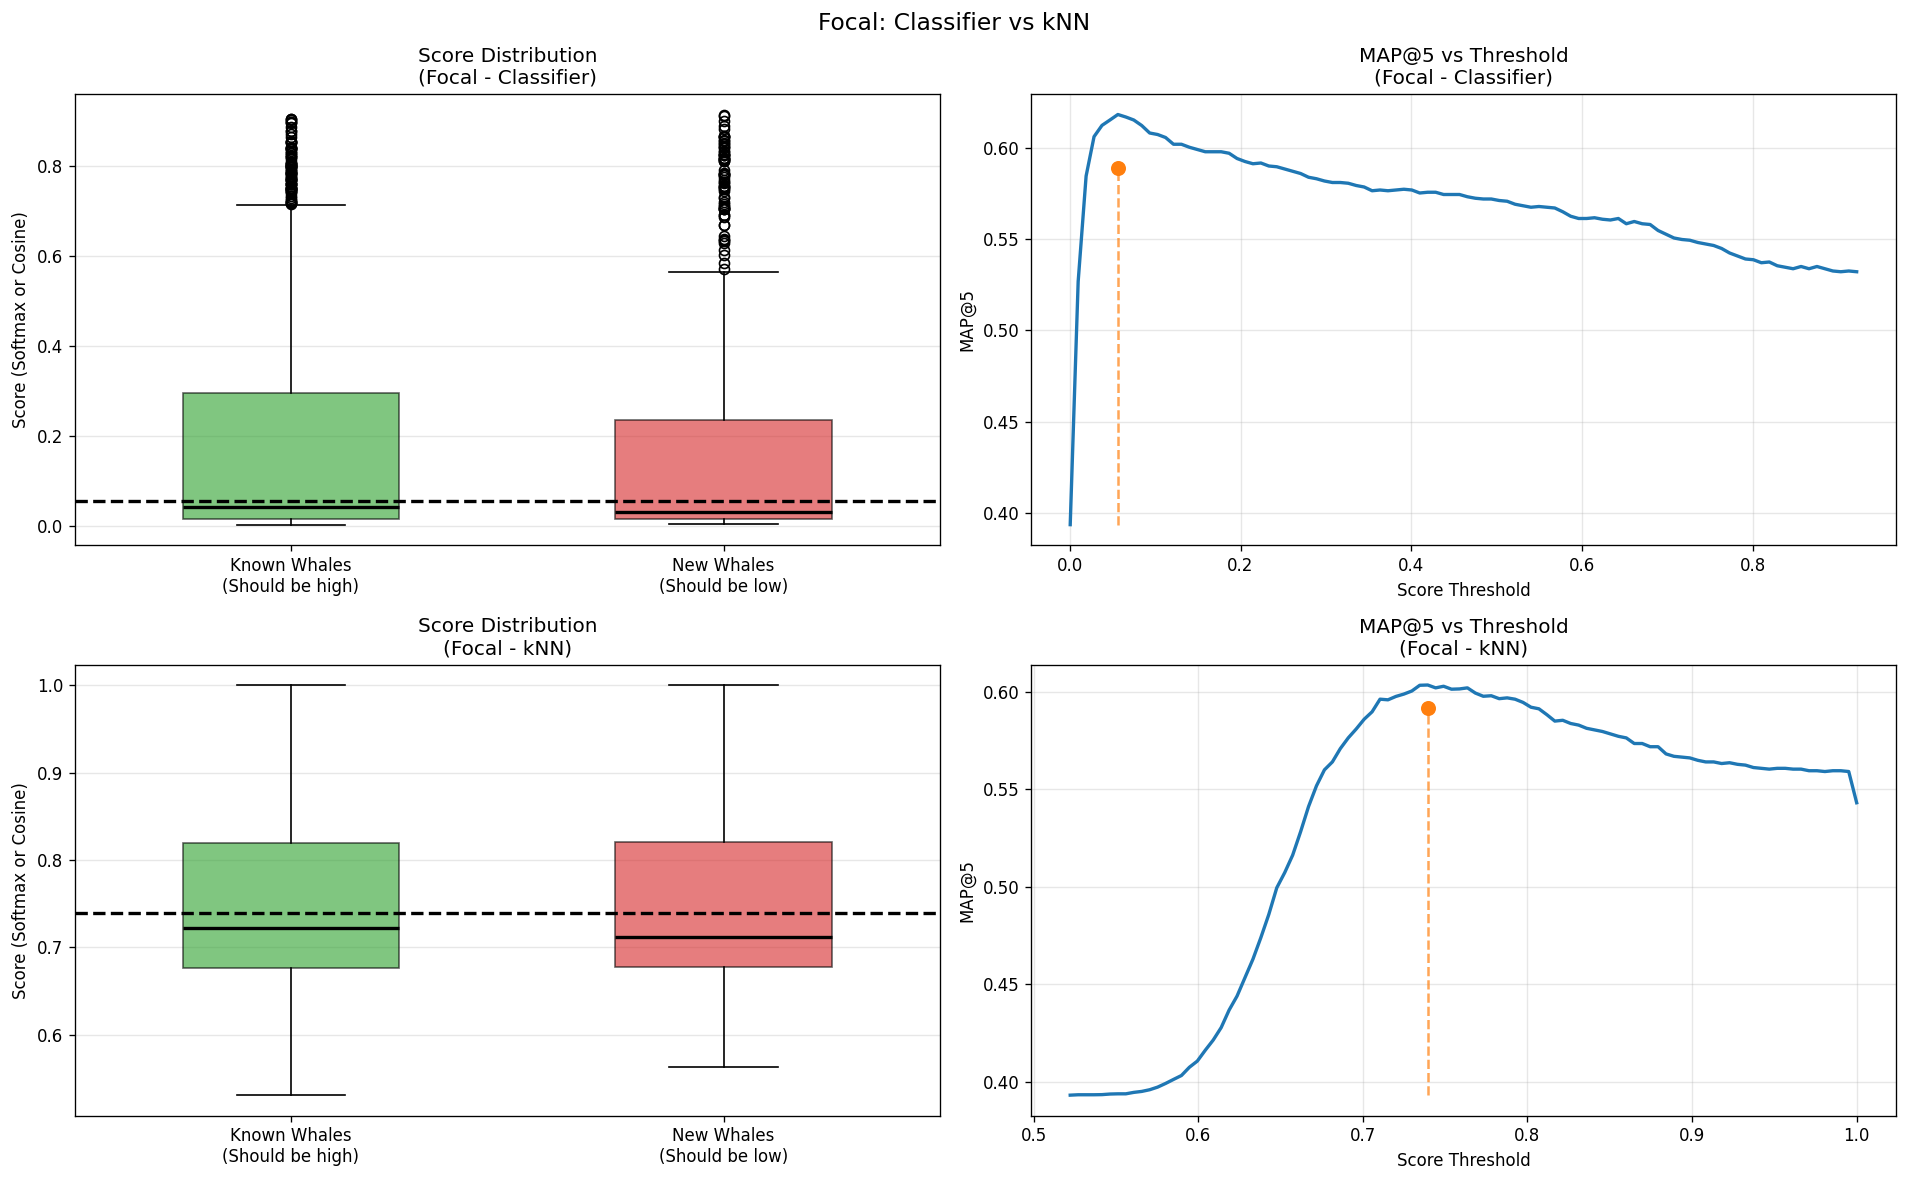

In [5]:
for run in runs:
    if run["run_id"] not in results:
        continue
    info = experiments[run["exp_key"]]
    print(f"\n=== {run['label']} (test) ===")
    config, data, model = load_experiment(
        info, mode=run["mode"]
    )

    if run["mode"] == "classifier":
        if config.head_type is None:
            print("  Skipping classifier mode because head_type is None")
            continue
        test_scores, test_preds, test_labels = get_classifier_predictions(
            model, test_loader, device
        )
    else:
        test_scores, test_preds, test_labels = get_retrieval_predictions(
            model, gallery_loader, test_loader, device
        )

    base_test_metrics = evaluate_base_metrics(test_scores, test_preds, test_labels)

    test_preds_np = test_preds.cpu().numpy()
    test_scores_np = test_scores.cpu().numpy()
    test_labels_np = test_labels.cpu().numpy()
    best_threshold = results[run["run_id"]]["best_threshold"]

    # Apply validation threshold to test predictions.
    final_test_preds = np.array([
        insert_new_whale(p, s, best_threshold)
        for p, s in zip(test_preds_np, test_scores_np)
    ])

    final_test_map5 = calculate_map5(final_test_preds, test_labels_np)

    results[run["run_id"]]["test_base_metrics"] = base_test_metrics
    results[run["run_id"]]["final_test_map5"] = final_test_map5
    results[run["run_id"]]["test_scores"] = test_scores
    results[run["run_id"]]["test_labels"] = test_labels

    print("Test Base Metrics:", base_test_metrics)
    print(f"Final Test MAP@5: {final_test_map5:.4f}")

    plot_evaluation(
        scores=test_scores,
        labels=test_labels,
        thresholds=results[run["run_id"]]["thresholds"],
        map5_scores=results[run["run_id"]]["map_scores"],
        best_threshold=best_threshold,
        best_map5=final_test_map5,
        model_name=run["label"],
    )

if "focal_cls" in results and "focal_knn" in results:
    plot_evaluation_pair(
        results["focal_cls"],
        results["focal_knn"],
        title="Focal: Classifier vs kNN",
    )